In [40]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
#read in all the words
words=open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
#build the vocabulary of characters and mapping to/from integers
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
#builds the dataset

block_size = 3 #context langth: how many characters so we take to predict the next one?
X, Y = [], []

for w in words:


    context=[0]*block_size
    for ch in w + '.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:] +[ix] #crop and append


X=torch.tensor(X)
Y=torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
#builds the dataset
def build_dataset(words):
    block_size = 3 #context langth: how many characters so we take to predict the next one?
    X, Y = [], []
    
    for w in words:
        
        context=[0]*block_size
        for ch in w + '.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:] +[ix] #crop and append
    
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape, Y.shape)f
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr =build_dataset(words[:n1])
Xdev, Ydev =build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
len(words)

32033

In [9]:
n1

25626

In [10]:
n2

28829

In [11]:
n2-n1

3203

In [12]:
len(words) - n2

3204

In [13]:
C=torch.randn((27,2))

In [14]:
emb=C[X]
emb.shape

torch.Size([228146, 3, 2])

In [15]:
W1=torch.randn((6, 100))
b1=torch.randn((100))

In [16]:
h=emb.view(-1, 6) @ W1+b1

In [17]:
h

tensor([[ 0.9951, -1.6146, -0.2473,  ..., -1.2058,  1.3314, -2.0285],
        [ 0.4729, -1.1508,  1.8891,  ..., -2.7960,  4.2693, -0.0973],
        [ 0.2175,  2.8825,  2.1652,  ..., -2.7277, -1.3603,  0.8014],
        ...,
        [ 1.5369,  1.2136, -2.0243,  ...,  1.7870, -0.7945, -2.6082],
        [-0.1622, -1.1186,  1.5359,  ...,  3.0137, -1.0176,  0.0687],
        [-0.7375,  2.6740, -3.4748,  ...,  3.2048, -4.1380,  1.0766]])

In [18]:
h=torch.tanh(emb.view(-1, 6) @ W1+b1)

In [19]:
h

tensor([[ 0.7595, -0.9238, -0.2424,  ..., -0.8354,  0.8696, -0.9660],
        [ 0.4405, -0.8180,  0.9553,  ..., -0.9926,  0.9996, -0.0970],
        [ 0.2141,  0.9937,  0.9740,  ..., -0.9915, -0.8765,  0.6648],
        ...,
        [ 0.9116,  0.8377, -0.9657,  ...,  0.9454, -0.6610, -0.9892],
        [-0.1608, -0.8071,  0.9114,  ...,  0.9952, -0.7689,  0.0685],
        [-0.6276,  0.9905, -0.9981,  ...,  0.9967, -0.9995,  0.7919]])

In [20]:
h.shape

torch.Size([228146, 100])

In [21]:
W2=torch.randn((100,27))
b2=torch.rand(27)

In [22]:
logits=h @ W2 + b2

In [23]:
logits.shape

torch.Size([228146, 27])

In [24]:
counts=logits.exp()

In [25]:
prob=counts / counts.sum(1, keepdims=True)

In [26]:
prob.shape

torch.Size([228146, 27])

In [27]:
loss=-prob[torch.arange(32), Y].log().mean()
loss

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [28]:
Xtr.shape, Ytr.shape #dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [29]:
g=torch.Generator().manual_seed(2147483647) # fpr reproducibility
C=torch.randn((27, 10), generator=g)
W1=torch.randn((30, 200), generator=g)
b1=torch.randn(200, generator=g)
W2=torch.randn((200,27), generator=g)
b2=torch.randn(27, generator=g)
parameters=[C, W1, b1, W2, b2]

In [30]:
sum(p.nelement() for p in parameters) #number of parameter in total

11897

In [31]:
for p in parameters:
    p.requires_grad=True

In [32]:
lre=torch.linspace(-3, 0, 1000)
lrs=10**lre

In [33]:
lri=[]
lossi=[]
stepi=[]

In [34]:

for i in  range(100):
    # minibach constructa
    ix=torch.randint(0, Xtr.shape[0], (32,))
    
    #forward pass
    emb=C[Xtr[ix]] #(32, 3, 2)
    h=torch.tanh(emb.view(-1, 30) @ W1+b1) #(32, 100)
    logits=h @ W2+b2 #(32, 27)
    #counts=logits.exp()
    #prob=counts / counts.sum(1, keepdims=True)
    #loss=-prob[torch.arange(32), Y].log().mean()
    loss=F.cross_entropy(logits,Ytr[ix])


    
    #backward pass
    for p in parameters:
        p.grad=None
    loss.backward()
    
    #update
    #lr = lrs[i]
    lr=0.005
    for p in parameters:
        p.data += -lr *p.grad

    #track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

19.041027069091797


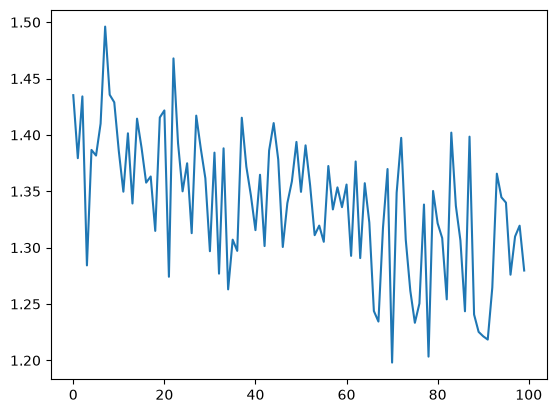

In [35]:
plt.plot(stepi, lossi)

In [36]:
emb=C[Xdev] #(32, 3, 2)
h=torch.tanh(emb.view(-1, 30) @ W1+b1) #(32, 100)
logits=h @ W2+b2 #(32, 27)
loss=F.cross_entropy(logits,Ydev)
loss

tensor(19.4210, grad_fn=<NllLossBackward0>)

In [37]:
emb=C[Xtr] #(32, 3, 2)
h=torch.tanh(emb.view(-1, 30) @ W1+b1) #(32, 100)
logits=h @ W2+b2 #(32, 27)
loss=F.cross_entropy(logits,Ytr)
loss

tensor(19.3897, grad_fn=<NllLossBackward0>)

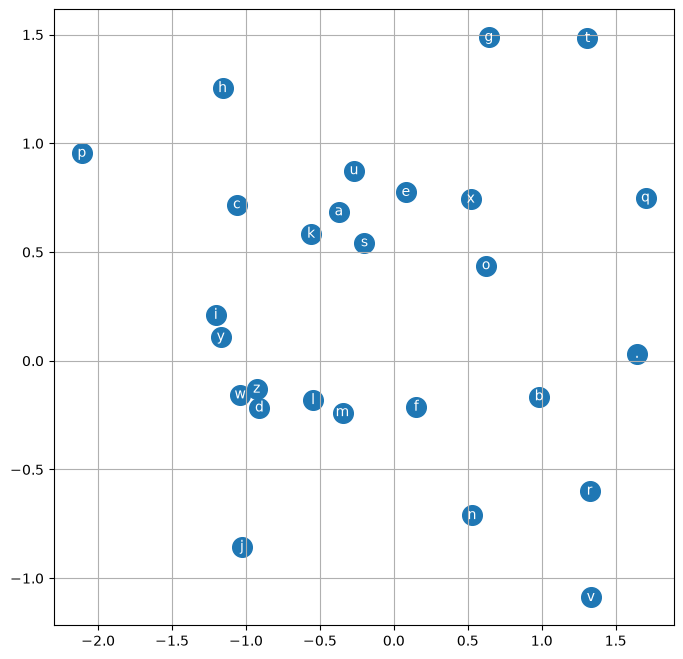

In [38]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va= "center", color="white")
plt.grid('minor')

In [39]:
#traing split, dev/validation slit, test split
#80%, 10%, 10%,    why not just not change the weight and bise for test split???
